<a href="https://colab.research.google.com/github/vummalreddysnehitha/AIML_VUMMAL-REDDY-SNEHITHA-REDDY/blob/main/AIML_Module_01_Lab_01_Features(SNEHITHA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting features from data

Module 1, Lab 1<br>



In [4]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=cfded719974bfeb159138fa51936b10a4191128b903ed89be8e946cb9e007907
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [5]:
print('hello world')

hello world


# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [6]:
!pip install wikipedia

import wikipedia
topic1 = 'Giraffe (animal)'
topic2 = 'Elephant'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

wikipedia.set_lang('fr')

fr1 = wikipedia.page(topic1).content
fr2 = wikipedia.page(topic2).content


This is what the text looks like:

In [7]:
fr2

'Les éléphants sont des mammifères proboscidiens de la famille des Éléphantidés. \nIls correspondent aujourd\'hui à trois espèces réparties en deux genres distincts. L\'éléphant de savane d\'Afrique et l\'éléphant de forêt d\'Afrique, autrefois regroupés sous la même espèce d\'« éléphant d\'Afrique », appartiennent au genre Loxodonta, tandis que l\'éléphant d\'Asie, anciennement appelé « éléphant indien », appartient au genre Elephas. Ils se différencient par certaines caractéristiques anatomiques, les éléphants d\'Asie étant en général plus petits avec des oreilles plus petites, ou encore une différence du bout de la trompe. Ces espèces survivantes font localement l\'objet de programmes ou de projets de réintroduction et de protection.\nLe mot français « éléphant » vient du mot latin elephantus qui tire son origine du grec ἐλέφας / eléphas, « ivoire » ou « éléphant ».\nL\'éléphant apparaît dans de nombreuses cultures. Il est symbole de sagesse en Asie et est  connu pour sa mémoire et 

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [8]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [9]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [10]:
print(eng1)

...


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [11]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and French pages. Can you spot a difference?

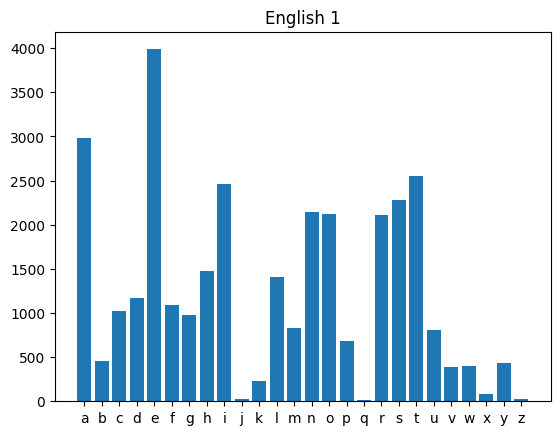

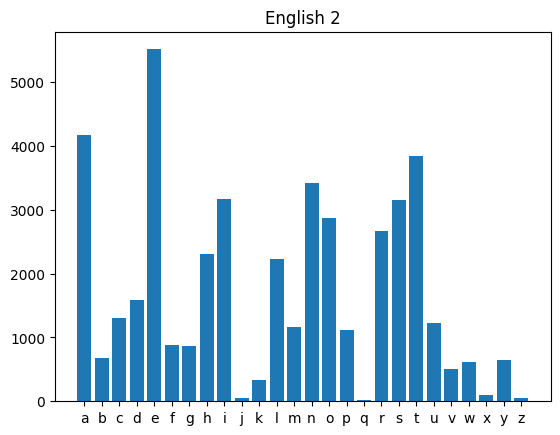

In [12]:
unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()
unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

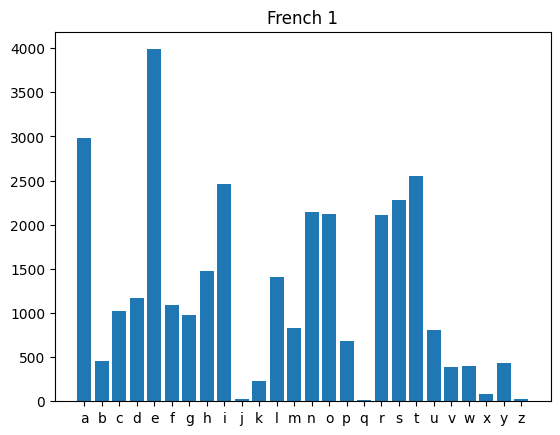

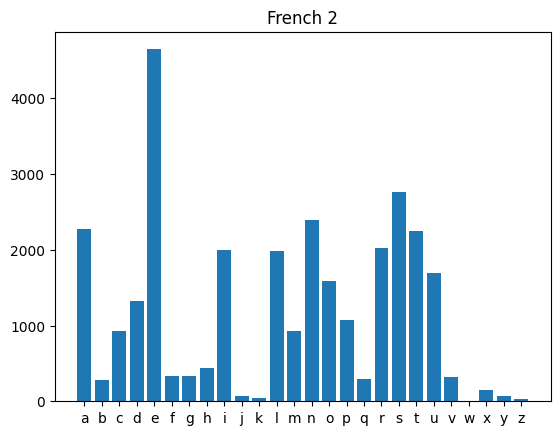

In [13]:
unigram_fr1 = Counter(ngrams(fr1,1))
plothistogram(unigram_eng1)
plt.title('French 1')
plt.show()
unigram_fr2 = Counter(ngrams(fr2,1))
plothistogram(unigram_fr2)
plt.title('French 2')
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

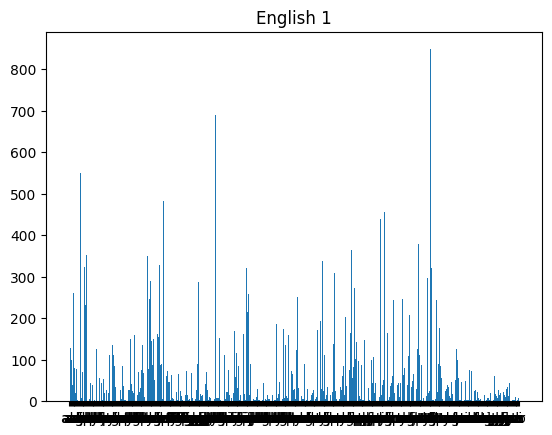

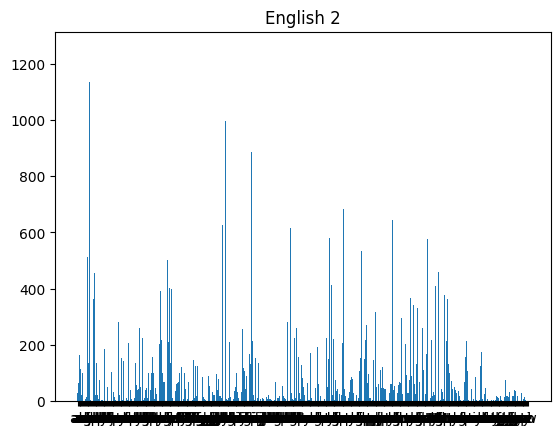

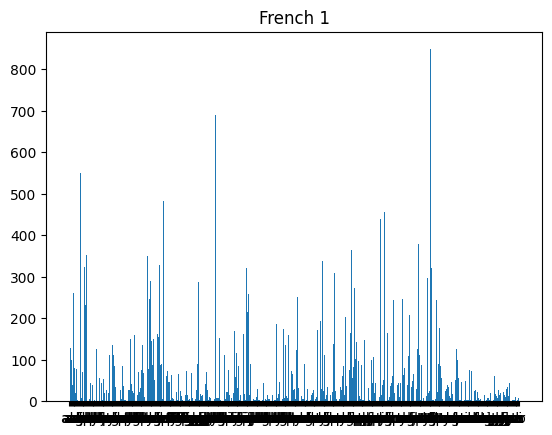

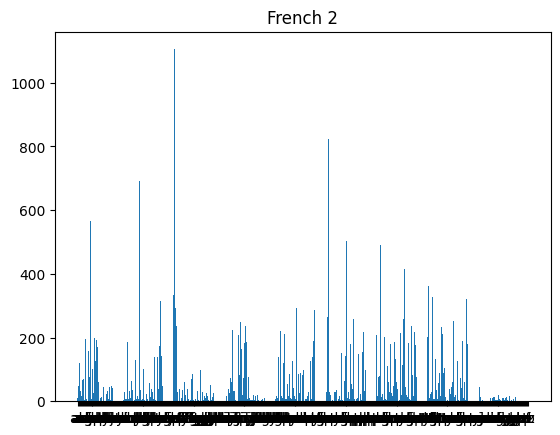

In [14]:
bigram_eng1 = Counter(ngrams(eng1,2)) # bigrams
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

bigram_fr1 = Counter(ngrams(fr1,2))
plothistogram(bigram_eng1)
plt.title('French 1')
plt.show()

bigram_fr2 = Counter(ngrams(fr2,2))
plothistogram(bigram_fr2)
plt.title('French 2')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [15]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

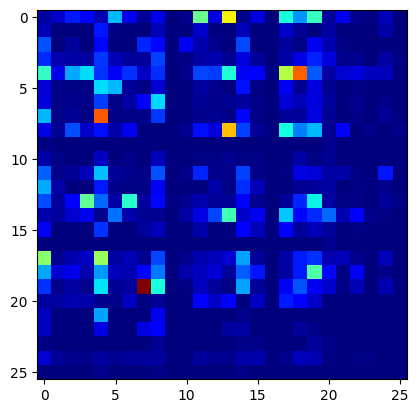

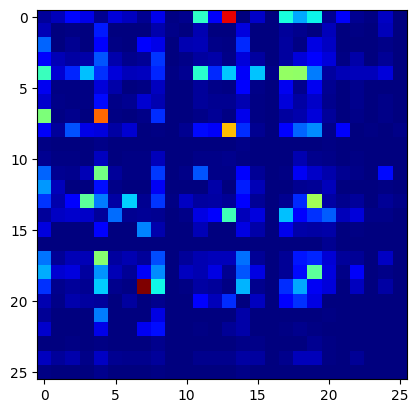

In [16]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()
bieng2 = plotbihistogram(bigram_eng2)

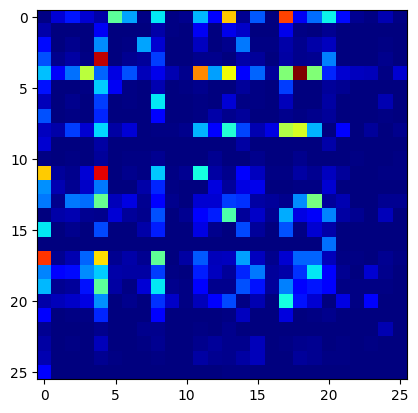

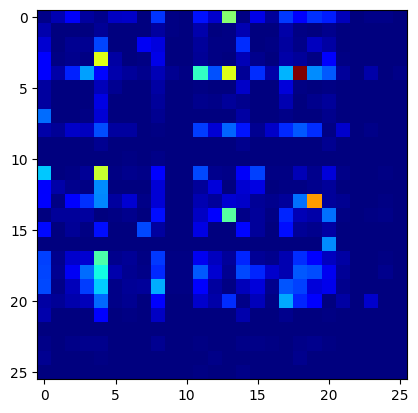

In [17]:
bifr1 = plotbihistogram(bigram_fr1)
plt.show()
bifr2 = plotbihistogram(bigram_fr2)

Let us look at the top 10 ngrams for each text.

In [18]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [19]:
print('\nEnglish 1:')
ShowTopN(bieng1)
print('\nEnglish 2:')
ShowTopN(bieng2)
print('\nFrench 1:')
ShowTopN(bifr1)
print('\nFrench 2:')
ShowTopN(bifr2)


English 1:
('t', 'h') : 848.0
('h', 'e') : 690.0
('e', 's') : 683.0
('i', 'n') : 598.0
('a', 'n') : 550.0
('e', 'r') : 482.0
('r', 'e') : 455.0
('r', 'a') : 438.0
('a', 'l') : 407.0
('n', 'd') : 397.0

English 2:
('t', 'h') : 1251.0
('a', 'n') : 1134.0
('h', 'e') : 997.0
('i', 'n') : 885.0
('n', 't') : 682.0
('e', 'r') : 662.0
('e', 's') : 656.0
('r', 'e') : 644.0
('h', 'a') : 628.0
('l', 'e') : 615.0

French 1:
('e', 's') : 156.0
('d', 'e') : 147.0
('l', 'e') : 142.0
('r', 'a') : 133.0
('a', 'r') : 131.0
('e', 'l') : 119.0
('a', 'n') : 109.0
('l', 'a') : 108.0
('r', 'e') : 105.0
('e', 'n') : 100.0

French 2:
('e', 's') : 1105.0
('n', 't') : 823.0
('d', 'e') : 690.0
('e', 'n') : 686.0
('l', 'e') : 652.0
('a', 'n') : 566.0
('o', 'n') : 504.0
('r', 'e') : 492.0
('e', 'l') : 456.0
('s', 'e') : 414.0


We observe that the bigrams are similar across different topics but different across languages. Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.

Thus, we were able to convert a many-dimensional input (the text) to 26 dimesions (unigrams) or 26*26 dimensions (bigrams).


A few ways to explore:
1. Try with different languages.
2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?
3. How can we use and visualize trigrams and higher n-grams?

testing the imported libraries

In [20]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd
text = "I LIVE IN INDIA , AND I LOVE INDIA ."

# 1. Split into sentences
sentences = re.split(r'[.!?]', text)
sentences = [s.strip() for s in sentences if s.strip()]

print("Sentences:")
for i, s in enumerate(sentences, 1):
    print(f"Sentence {i}: {s}")

# 2. Manipulation (*2)
text2 = text * 2
print("\nText multiplied by 2:")
print(text2)

# 3. Remove punctuation
clean_text = re.sub(r'[^\w\s]', '', text2)
print("\nText without punctuation:")
print(clean_text)

# 4. Count repeated words
words = clean_text.lower().split()
word_count = Counter(words)

print("\nWord Frequency:")
for word, count in word_count.items():
    print(word, ":", count)

Sentences:
Sentence 1: I LIVE IN INDIA , AND I LOVE INDIA

Text multiplied by 2:
I LIVE IN INDIA , AND I LOVE INDIA .I LIVE IN INDIA , AND I LOVE INDIA .

Text without punctuation:
I LIVE IN INDIA  AND I LOVE INDIA I LIVE IN INDIA  AND I LOVE INDIA 

Word Frequency:
i : 4
live : 2
in : 2
india : 4
and : 2
love : 2


In [21]:
!pip install wikipedia

import wikipedia

topic1 = "Tiger (animal)"
topic2 = "Elephant"

# German articles
wikipedia.set_lang('de')
ger1 = wikipedia.page(topic1).content
ger2 = wikipedia.page(topic2).content

# Italian articles
wikipedia.set_lang('it')
it1 = wikipedia.page(topic1).content
it2 = wikipedia.page(topic2).content

print(ger1[:200])
print(ger2[:200])
print(it1[:200])
print(it2[:200])

Der Königstiger (Panthera tigris tigris), auch Bengal-Tiger oder Indischer Tiger, ist eine Unterart des Tigers, die zu den Festlandsunterarten zählt. Er ist auf dem Indischen Subkontinent verbreitet u
Die Elefanten (Elephantidae) sind eine Familie aus der Ordnung der Rüsseltiere. Die Familie stellt die größten gegenwärtig lebenden Landtiere und schließt außerdem die einzigen heute noch lebenden Ver
Questo è un elenco dei principali personaggi delle serie televisive dei Power Rangers, prodotte prima dalla Saban e in seguito dalla Disney e ispirate alle stagioni delle serie televisive giapponese S
The Elephant Man è un film biografico del 1980 diretto da David Lynch.
Il film è stato adattato dai libri The Elephant Man and Other Reminiscences del dottor Frederick Treves e The Elephant Man: A Stu


In [22]:
import re
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [23]:
ger1 = cleanup(ger1)
ger2 = cleanup(ger2)
it1 = cleanup(it1)
it2 = cleanup(it2)

In [24]:
print(ger1)
print(it1)

...


In [25]:
print(ger2)
print(it2)

...


In [26]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

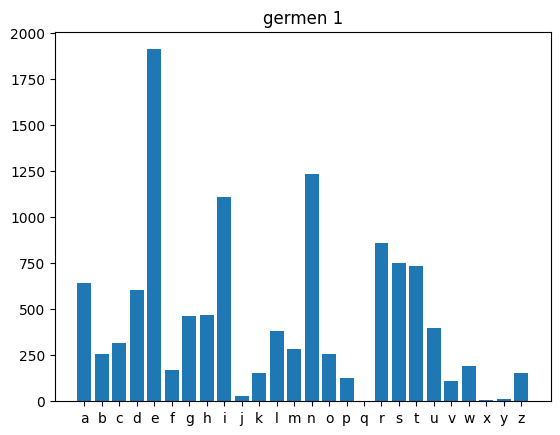

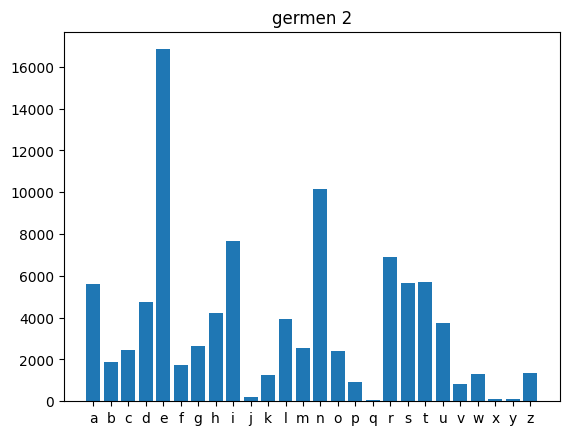

In [27]:
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
unigram_ger1 = Counter(ngrams(ger1,1))
plothistogram(unigram_ger1)
plt.title('germen 1')
plt.show()
unigram_ger2 = Counter(ngrams(ger2,1))
plothistogram(unigram_ger2)
plt.title('germen 2')
plt.show()

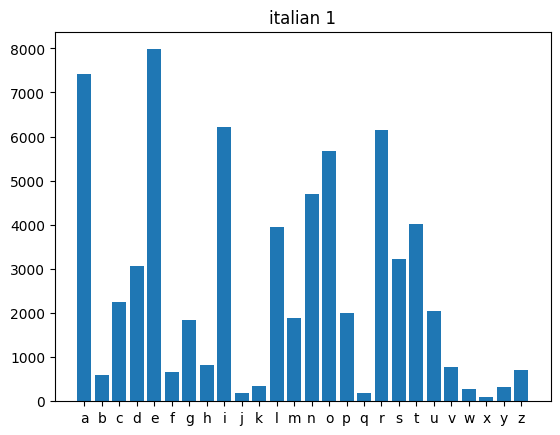

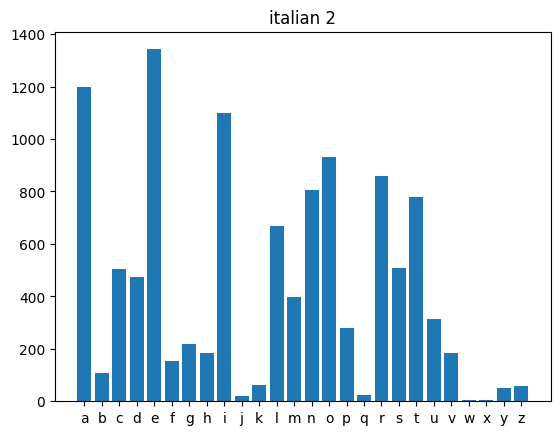

In [28]:
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
unigram_it1 = Counter(ngrams(it1,1))
plothistogram(unigram_it1)
plt.title('italian 1')
plt.show()
unigram_it2 = Counter(ngrams(it2,1))
plothistogram(unigram_it2)
plt.title('italian 2')
plt.show()

OBSERVATION:If we plot histograph for unigrams for 2 different languages(here i took germen and italian)there is only slight difference between the graph between languages and also between different topics in a same language So,unigram is not the best method for distinguishing languages

TESTING the histograph for unigrams without removing special characters

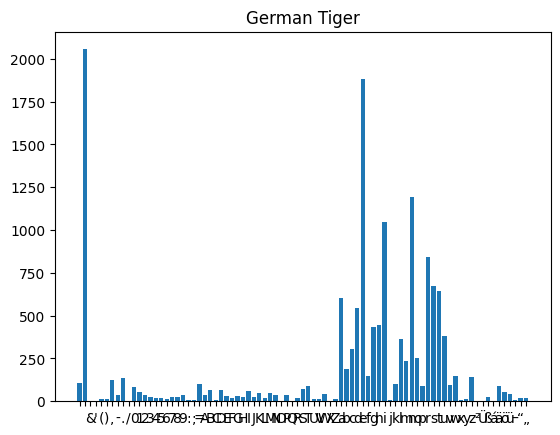

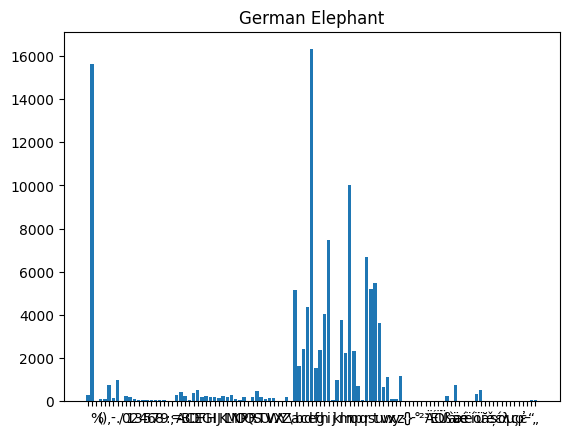

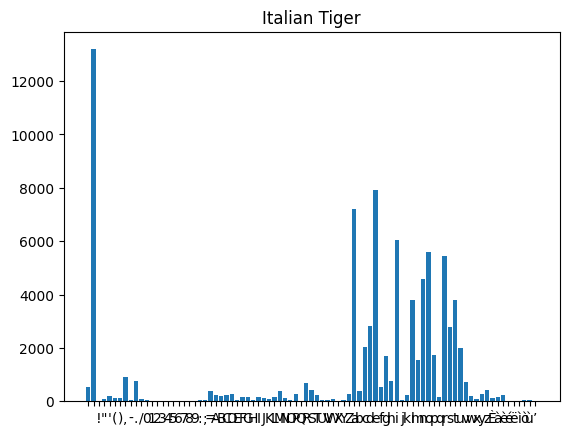

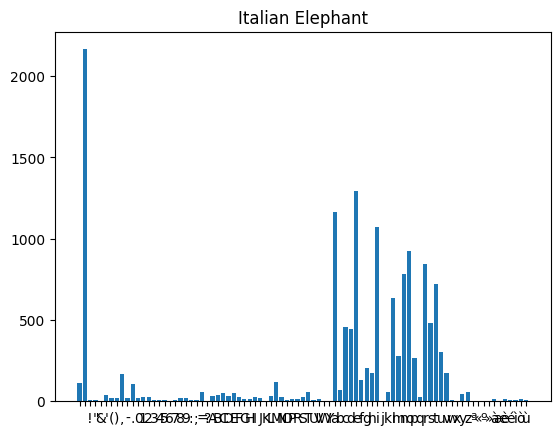

In [29]:
# install wikipedia
!pip install wikipedia

# import libraries
import wikipedia
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt

# topics (avoid disambiguation)
topic1 = "Tiger (animal)"
topic2 = "Elephant"

# ---------- GERMAN ----------
wikipedia.set_lang('de')

ger1 = wikipedia.page(topic1).content
ger2 = wikipedia.page(topic2).content

# ---------- ITALIAN ----------
wikipedia.set_lang('it')

it1 = wikipedia.page(topic1).content
it2 = wikipedia.page(topic2).content


# convert tuple to string
def tuple2string(tup):
    st = ''
    for ii in tup:
        st = st + ii
    return st


# convert tuple keys to string
def key2string(keys):
    return [tuple2string(i) for i in keys]


# function to plot histogram
def plothistogram(ngram):
    keys = key2string(ngram.keys())
    values = list(ngram.values())

    combined = zip(keys, values)

    # sort alphabetically
    zipped_sorted = sorted(combined, key=lambda x: x[0])
    keys, values = map(list, zip(*zipped_sorted))

    plt.bar(keys, values)


# ---------- GERMAN HISTOGRAMS ----------

unigram_ger1 = Counter(ngrams(ger1,1))
plothistogram(unigram_ger1)
plt.title('German Tiger')
plt.show()

unigram_ger2 = Counter(ngrams(ger2,1))
plothistogram(unigram_ger2)
plt.title('German Elephant')
plt.show()


# ---------- ITALIAN HISTOGRAMS ----------

unigram_it1 = Counter(ngrams(it1,1))
plothistogram(unigram_it1)
plt.title('Italian Tiger')
plt.show()

unigram_it2 = Counter(ngrams(it2,1))
plothistogram(unigram_it2)
plt.title('Italian Elephant')
plt.show()


EVEN IN THIS CASE, We can see that the unigrams for germen and italian are very similar. So this is not a good feature if we want to distinguish between different languages.

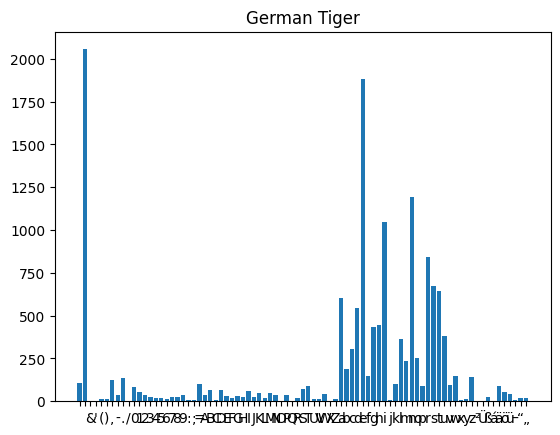

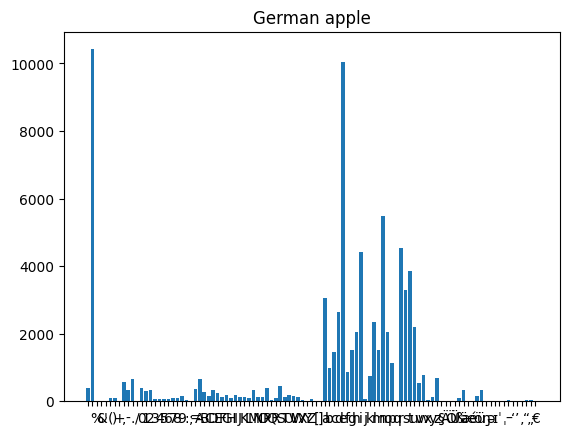

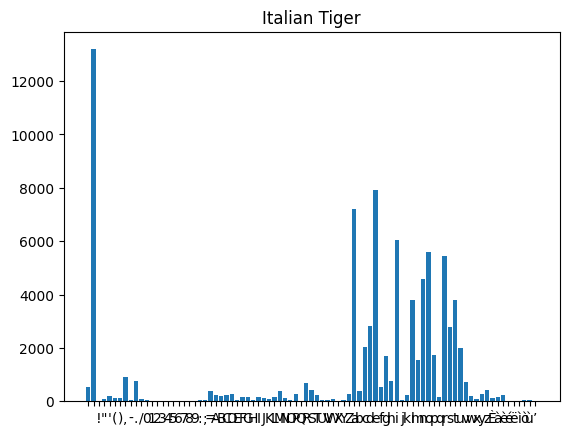

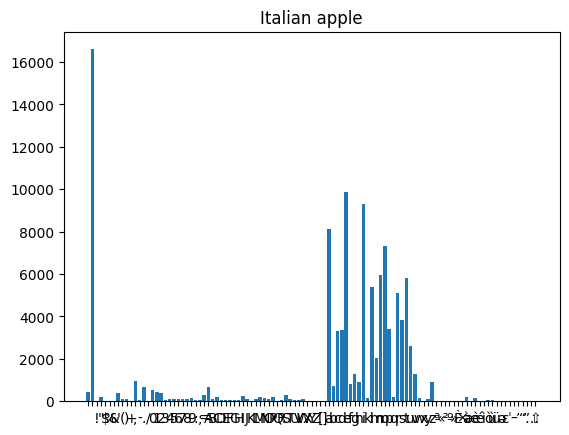

In [30]:
# install wikipedia
!pip install wikipedia

# import libraries
import wikipedia
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt

# topics (avoid disambiguation)
topic1 = "Tiger (animal)"
topic2 = "apple"

# ---------- GERMAN ----------
wikipedia.set_lang('de')

ger1 = wikipedia.page(topic1).content
ger2 = wikipedia.page(topic2).content

# ---------- ITALIAN ----------
wikipedia.set_lang('it')

it1 = wikipedia.page(topic1).content
it2 = wikipedia.page(topic2).content


# convert tuple to string
def tuple2string(tup):
    st = ''
    for ii in tup:
        st = st + ii
    return st


# convert tuple keys to string
def key2string(keys):
    return [tuple2string(i) for i in keys]


# function to plot histogram
def plothistogram(ngram):
    keys = key2string(ngram.keys())
    values = list(ngram.values())

    combined = zip(keys, values)

    # sort alphabetically
    zipped_sorted = sorted(combined, key=lambda x: x[0])
    keys, values = map(list, zip(*zipped_sorted))

    plt.bar(keys, values)


# ---------- GERMAN HISTOGRAMS ----------

unigram_ger1 = Counter(ngrams(ger1,1))
plothistogram(unigram_ger1)
plt.title('German Tiger')
plt.show()

unigram_ger2 = Counter(ngrams(ger2,1))
plothistogram(unigram_ger2)
plt.title('German apple')
plt.show()


# ---------- ITALIAN HISTOGRAMS ----------

unigram_it1 = Counter(ngrams(it1,1))
plothistogram(unigram_it1)
plt.title('Italian Tiger')
plt.show()

unigram_it2 = Counter(ngrams(it2,1))
plothistogram(unigram_it2)
plt.title('Italian apple')
plt.show()


EVEN IF WE,plot histographs for unigrams if 2 non related topics in 2 different topics their are similarities THUS,So this is not a good feature if we want to distinguish between different languages.

NOW LETS TEST WITH BIGRAMS

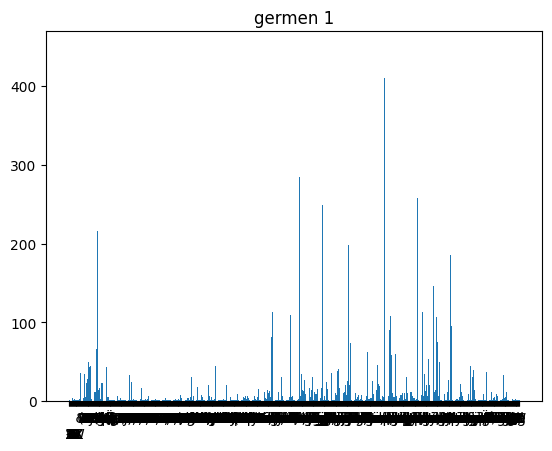

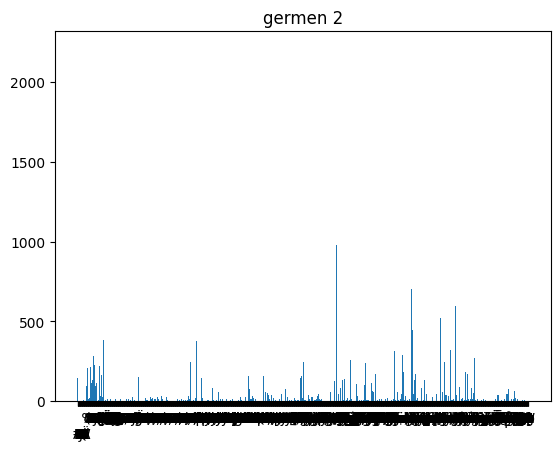

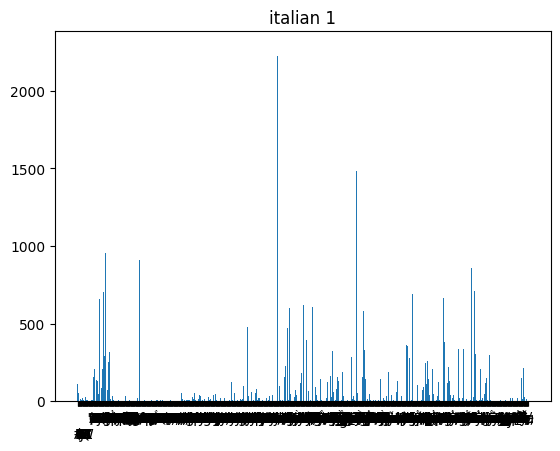

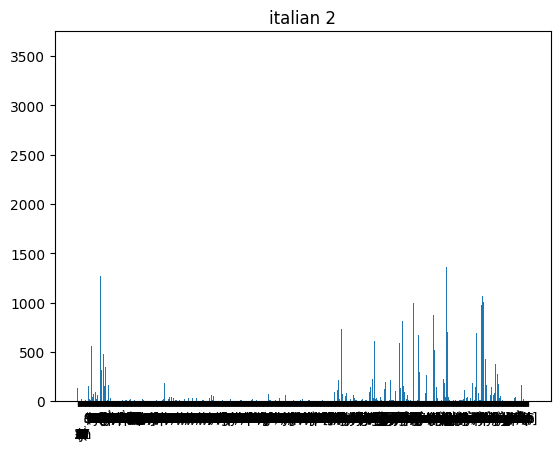

In [31]:
bigram_ger1 = Counter(ngrams(ger1,2)) # bigrams
plothistogram(bigram_ger1)
plt.title('germen 1')
plt.show()

bigram_ger2 = Counter(ngrams(ger2,2))
plothistogram(bigram_ger2)
plt.title('germen 2')
plt.show()

bigram_it1 = Counter(ngrams(it1,2))
plothistogram(bigram_it1)
plt.title('italian 1')
plt.show()

bigram_it2 = Counter(ngrams(it2,2))
plothistogram(bigram_it2)
plt.title('italian 2')
plt.show()

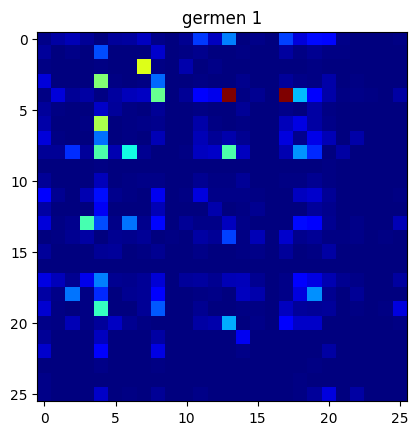

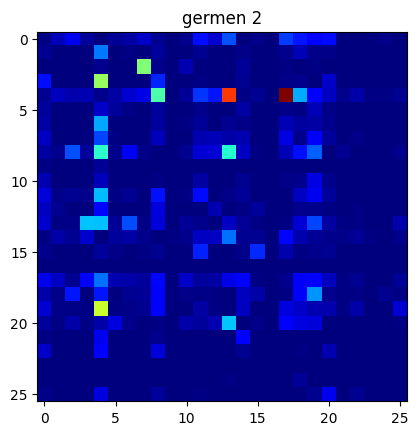

In [32]:
import numpy as np
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq
biger1 = plotbihistogram(bigram_ger1)
plt.title('germen 1')
plt.show()
biger2 = plotbihistogram(bigram_ger2)
plt.title('germen 2')
plt.show()

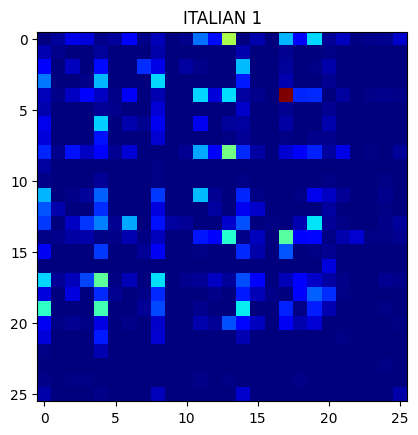

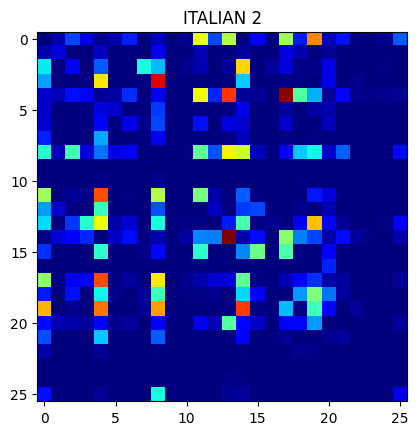

In [33]:
biit1 = plotbihistogram(bigram_it1)
plt.title('ITALIAN 1')
plt.show()
biit2 = plotbihistogram(bigram_it2)
plt.title('ITALIAN 2')
plt.show()

OBSERVATION:The bigrams are similar across different topics(in apple case there is a little difference but in most of the cases they are similar) but different across languages(GERMEN AND ITALIAN). Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.HERE THE TESTING IS DONE FOR 2 DIFFERENT TOPICS i.e TIGER AND APPLE

MANUAL TEXT TESTING(INSTEAD OF IMPORTING TEXT FROM Wikipedia)

In [58]:
text_news = """
Elephants are facing habitat loss due to deforestation.
Conservation programs are trying to protect wildlife.
"""

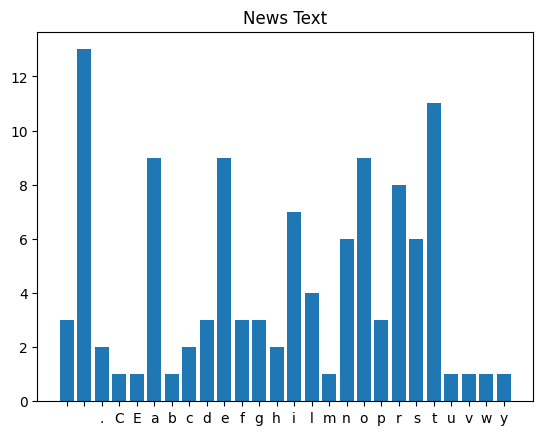

In [59]:
uni_news = Counter(ngrams(text_news,1))
plothistogram(uni_news)
plt.title("News Text")
plt.show()

Visualizing Trigrams

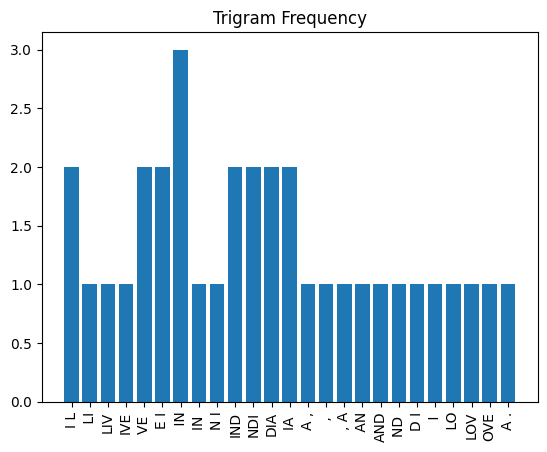

In [56]:
tri = Counter(ngrams(text,3))

keys = [''.join(k) for k in tri.keys()]
values = list(tri.values())

plt.bar(keys[:30], values[:30])
plt.xticks(rotation=90)
plt.title("Trigram Frequency")
plt.show()

TESTING Higher N-grams(4 GRAMS)

In [57]:
fourgram = Counter(ngrams(text,4))
print(list(fourgram.items())[:10])

[(('I', ' ', 'L', 'I'), 1), ((' ', 'L', 'I', 'V'), 1), (('L', 'I', 'V', 'E'), 1), (('I', 'V', 'E', ' '), 1), (('V', 'E', ' ', 'I'), 2), (('E', ' ', 'I', 'N'), 2), ((' ', 'I', 'N', ' '), 1), (('I', 'N', ' ', 'I'), 1), (('N', ' ', 'I', 'N'), 1), ((' ', 'I', 'N', 'D'), 2)]


Higher n-grams capture more context than unigrams.

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [34]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extract a subset of the data for our experiment:

In [35]:
no1 = train_X[train_y==1,:,:]
no0 = train_X[train_y==0,:,:]

Let us visualize a few images here:

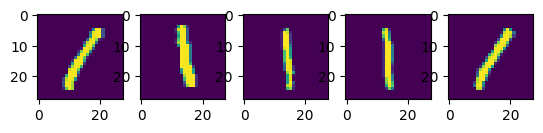

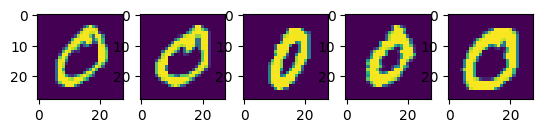

In [36]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no1[ii,:,:])
plt.show()
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no0[ii,:,:])
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [37]:
sum1 = np.sum(no1>0, (1,2)) # threshold before adding up
sum0 = np.sum(no0>0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

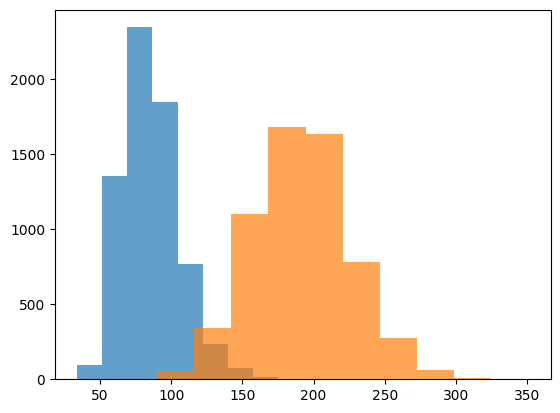

In [38]:
plt.hist(sum1, alpha=0.7);
plt.hist(sum0, alpha=0.7);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [39]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

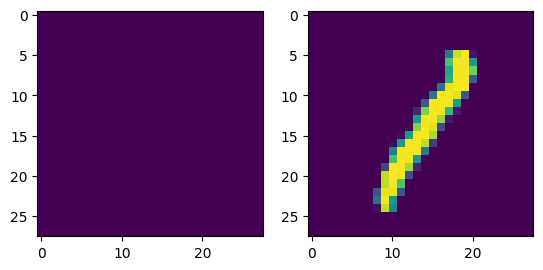

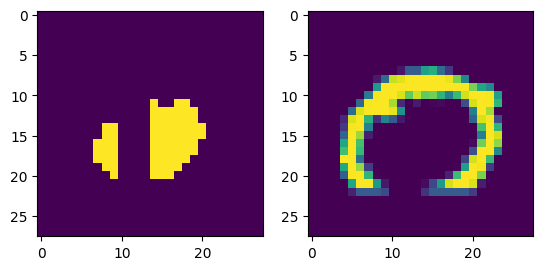

In [40]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

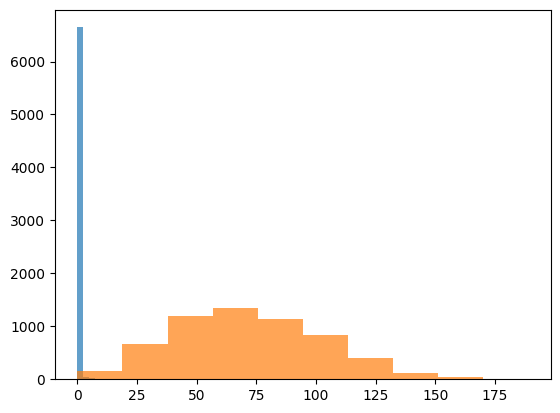

In [41]:
hole1 = np.array([getHolePixels(i).sum() for i in no1])
hole0 = np.array([getHolePixels(i).sum() for i in no0])

plt.hist(hole1, alpha=0.7);
plt.hist(hole0, alpha=0.7);

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [42]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

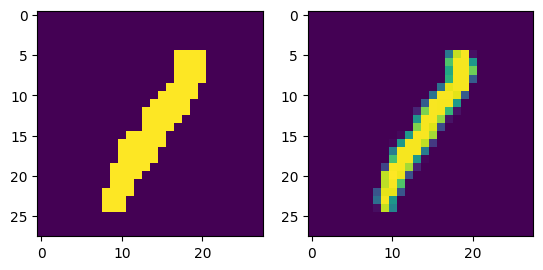

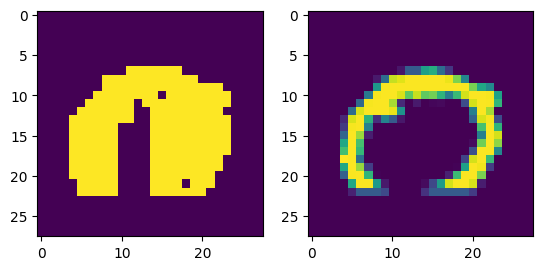

In [43]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Plotting the number of hull pixels versus the digit:

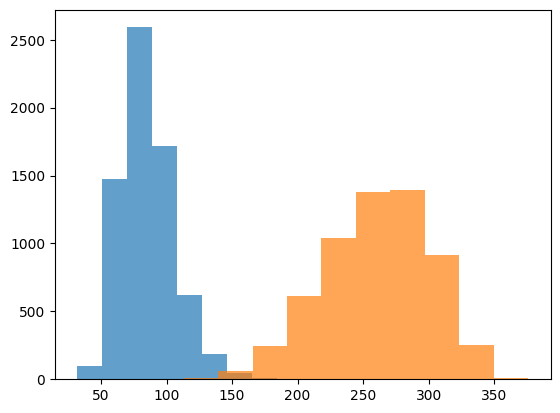

In [44]:
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

plt.hist(hull1, alpha=0.7);
plt.hist(hull0, alpha=0.7);

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [45]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

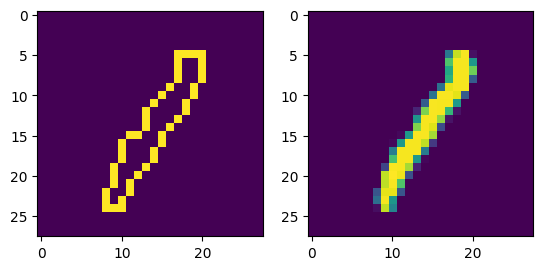

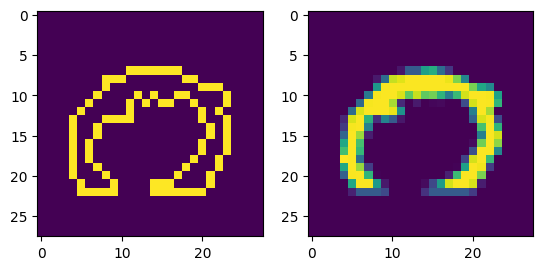

In [46]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

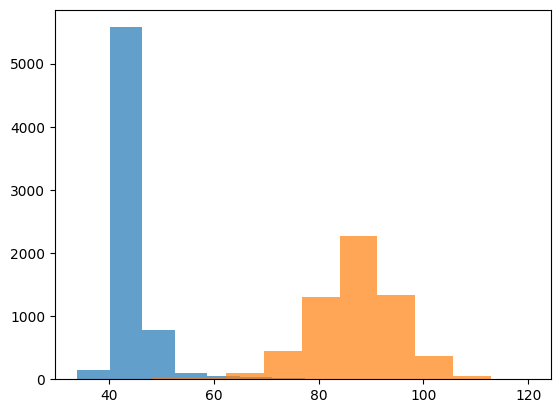

In [47]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0= np.array([getBoundaryPixels(i).sum() for i in no0])

plt.hist(bound1, alpha=0.7);
plt.hist(bound0, alpha=0.7);

What will happen if we plot two features together?

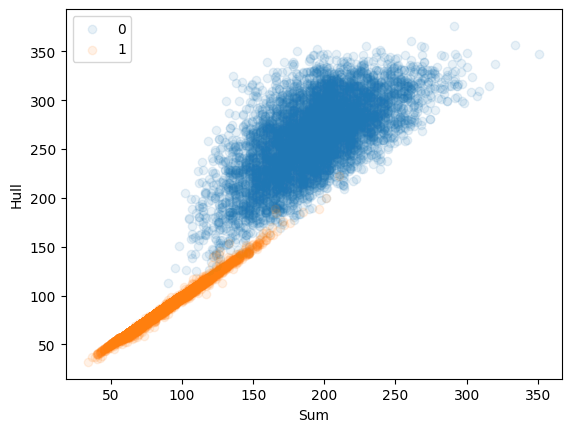

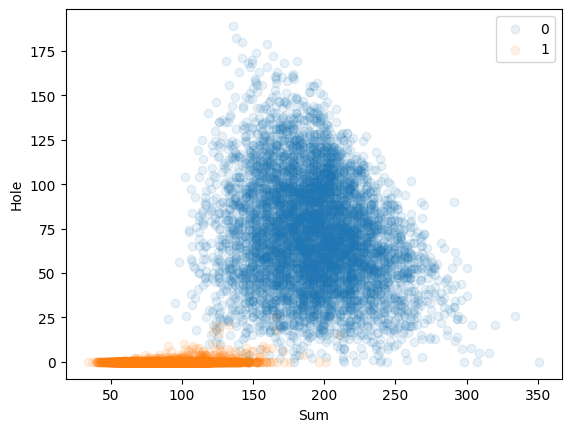

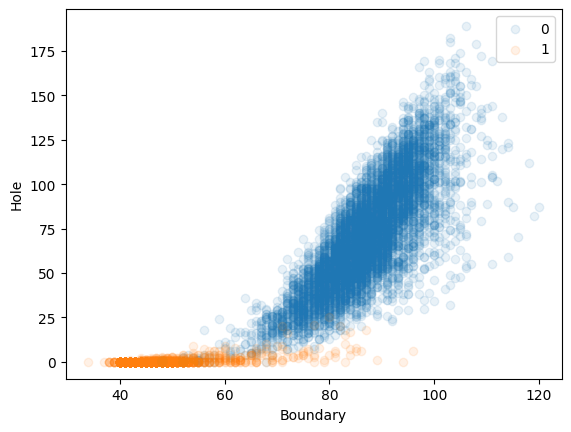

In [48]:
# Sum and hull
plt.scatter(sum0, hull0, alpha=0.1)
plt.scatter(sum1, hull1, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0','1'])
plt.show()

# Sum and hole
plt.scatter(sum0, hole0, alpha=0.1)
plt.scatter(sum1, hole1, alpha=0.1)
plt.xlabel('Sum');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

# Hole and boundary
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound1, hole1, alpha=0.1)
plt.xlabel('Boundary');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

Now let us try plotting 3 features together.

In [49]:
cl1 = ['class 1']*len(sum1)
cl0 = ['class 0']*len(sum0)
df = pd.DataFrame(list(zip(np.concatenate((hole0, hole0)), np.concatenate((sum1,sum0)),
                           np.concatenate((bound1,bound0)), np.concatenate((cl1, cl0)))),
               columns =['Hole', 'Sum', 'Boundary', 'Class'])
df.head()
fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()

Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?
2. How would you test or visualize four or more features?
3. Can you come up with your own features?
4. Will these features work for different classes other than 0 and 1?
5. What will happen if we take more that two classes at a time?

Which is the best combination of features?

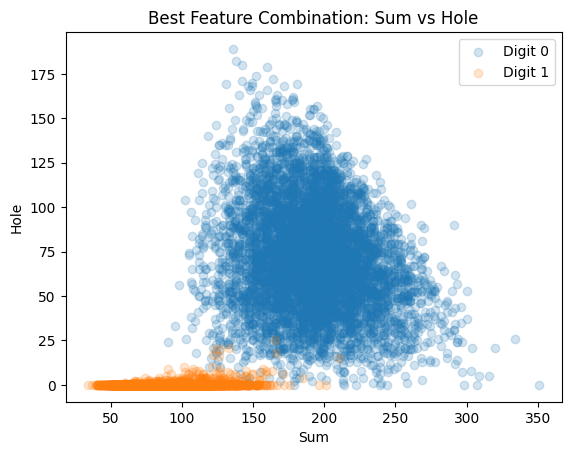

In [50]:
import matplotlib.pyplot as plt
plt.scatter(sum0, hole0, alpha=0.2)
plt.scatter(sum1, hole1, alpha=0.2)
plt.xlabel("Sum")
plt.ylabel("Hole")
plt.legend(["Digit 0","Digit 1"])
plt.title("Best Feature Combination: Sum vs Hole")
plt.show()

Hole + Sum provides the best separation between digits 0 and 1

How would you test or visualize four or more features?

In [51]:
fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary',
                    color='Class', opacity=0.2)
fig.show()

3D visualization helps explore relationships between multiple features simultaneously.

Create Your Own Feature

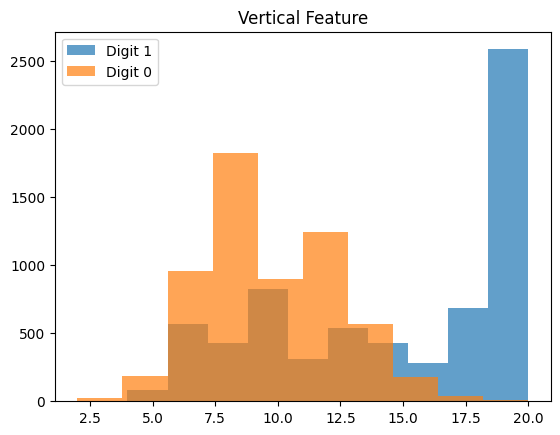

In [52]:
def verticalFeature(img):
    return np.sum(img[:,14] > 0)   # middle column

v1 = np.array([verticalFeature(i) for i in no1])
v0 = np.array([verticalFeature(i) for i in no0])

plt.hist(v1, alpha=0.7)
plt.hist(v0, alpha=0.7)
plt.title("Vertical Feature")
plt.legend(["Digit 1","Digit 0"])
plt.show()

Vertical pixel density is higher for digit 1 due to its vertical structure.

Will These Features Work for Other Digits?

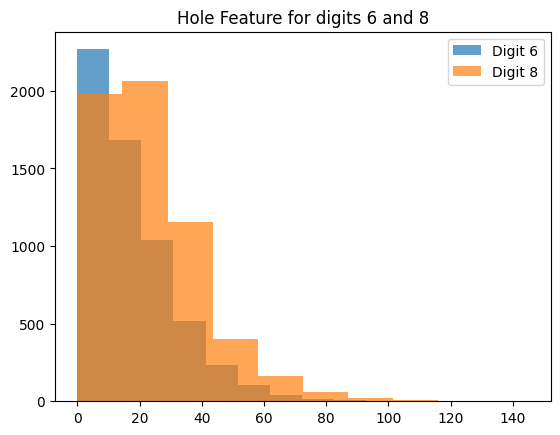

In [53]:
no6 = train_X[train_y==6,:,:]
no8 = train_X[train_y==8,:,:]

hole6 = np.array([getHolePixels(i).sum() for i in no6])
hole8 = np.array([getHolePixels(i).sum() for i in no8])

plt.hist(hole6, alpha=0.7)
plt.hist(hole8, alpha=0.7)
plt.legend(["Digit 6","Digit 8"])
plt.title("Hole Feature for digits 6 and 8")
plt.show()

Hole feature cannot distinguish digits 6 and 8 because both contain holes

What Happens With More Than Two Classes?

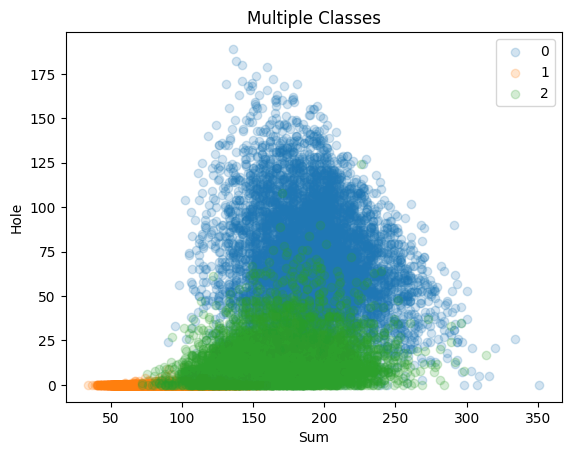

In [54]:
no2 = train_X[train_y==2,:,:]

sum2 = np.sum(no2>0,(1,2))
hole2 = np.array([getHolePixels(i).sum() for i in no2])

plt.scatter(sum0, hole0, alpha=0.2)
plt.scatter(sum1, hole1, alpha=0.2)
plt.scatter(sum2, hole2, alpha=0.2)

plt.xlabel("Sum")
plt.ylabel("Hole")
plt.legend(["0","1","2"])
plt.title("Multiple Classes")
plt.show()

When more classes are added, feature overlap increases and classification becomes harder